# Module 6 / Class 5 - LSTM vs Logistic Regression on IMDB

This notebook completes the IMDB sentiment assignment. It builds a
TF-IDF Logistic Regression baseline, trains an LSTM, compares
accuracy and training time, and answers the final comparison
questions.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import Markdown, display

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
tf.keras.utils.set_random_seed(42)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Load IMDB Dataset

IMDB reviews are loaded as integer word IDs. A CPU-friendly subset
is used so both models can be trained and compared locally.

In [2]:
VOCAB_SIZE = 10000
MAXLEN = 160

(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

train_count = 5000
valid_count = 1000
test_count = 2000

x_train_seq = x_train_full[:train_count]
y_train = y_train_full[:train_count]
x_valid_seq = x_train_full[train_count:train_count + valid_count]
y_valid = y_train_full[train_count:train_count + valid_count]
x_test_seq = x_test_full[:test_count]
y_test = y_test_full[:test_count]

print("train:", len(x_train_seq), "valid:", len(x_valid_seq), "test:", len(x_test_seq))
print("first review length:", len(x_train_seq[0]))

train: 5000 valid: 1000 test: 2000
first review length: 218


In [3]:
word_index = keras.datasets.imdb.get_word_index()
reverse_index = {value + 3: key for key, value in word_index.items()}
reverse_index[0] = "<PAD>"
reverse_index[1] = "<START>"
reverse_index[2] = "<UNK>"
reverse_index[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join(reverse_index.get(token, "?") for token in sequence)

print(decode_review(x_train_seq[0][:50]))
print("label:", "positive" if y_train[0] == 1 else "negative")

      0/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  16384/1641221 ━━━━━━━━━━━━━━━━━━━━ 14s 9us/step

  24576/1641221 ━━━━━━━━━━━━━━━━━━━━ 13s 8us/step

  32768/1641221 ━━━━━━━━━━━━━━━━━━━━ 12s 8us/step

  57344/1641221 ━━━━━━━━━━━━━━━━━━━━ 11s 7us/step

...

1294336/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

1474560/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved


label: positive


## 2. Baseline: TF-IDF + Logistic Regression

TF-IDF turns each review into weighted word features. Logistic
Regression is a strong, simple baseline for text classification.

In [4]:
train_texts = [decode_review(review) for review in x_train_seq]
valid_texts = [decode_review(review) for review in x_valid_seq]
test_texts = [decode_review(review) for review in x_test_seq]

start_time = time.perf_counter()

tfidf = TfidfVectorizer(max_features=5000, min_df=2)
x_train_tfidf = tfidf.fit_transform(train_texts)
x_valid_tfidf = tfidf.transform(valid_texts)
x_test_tfidf = tfidf.transform(test_texts)

lr_model = LogisticRegression(max_iter=1000, solver="liblinear")
lr_model.fit(x_train_tfidf, y_train)

logreg_train_seconds = time.perf_counter() - start_time
logreg_valid_acc = accuracy_score(y_valid, lr_model.predict(x_valid_tfidf))
logreg_test_acc = accuracy_score(y_test, lr_model.predict(x_test_tfidf))

print(f"TF-IDF shape: {x_train_tfidf.shape}")
print(f"LogReg validation accuracy: {logreg_valid_acc:.4f}")
print(f"LogReg test accuracy: {logreg_test_acc:.4f}")
print(f"LogReg training seconds: {logreg_train_seconds:.2f}")

TF-IDF shape: (5000, 5000)
LogReg validation accuracy: 0.8590
LogReg test accuracy: 0.8600
LogReg training seconds: 3.86


## 3. LSTM Model

The LSTM reads token sequences in order. Padding makes every
sequence the same length.

In [5]:
x_train_pad = keras.preprocessing.sequence.pad_sequences(x_train_seq, maxlen=MAXLEN)
x_valid_pad = keras.preprocessing.sequence.pad_sequences(x_valid_seq, maxlen=MAXLEN)
x_test_pad = keras.preprocessing.sequence.pad_sequences(x_test_seq, maxlen=MAXLEN)

print("padded train shape:", x_train_pad.shape)

padded train shape: (5000, 160)


In [6]:
keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

lstm_model = keras.Sequential([
    layers.Input(shape=(MAXLEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=32),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid"),
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

start_time = time.perf_counter()
lstm_history = lstm_model.fit(
    x_train_pad,
    y_train,
    validation_data=(x_valid_pad, y_valid),
    epochs=3,
    batch_size=128,
    verbose=0,
)
lstm_train_seconds = time.perf_counter() - start_time

lstm_test_loss, lstm_test_acc = lstm_model.evaluate(x_test_pad, y_test, verbose=0)
lstm_valid_acc = lstm_history.history["val_accuracy"][-1]

print(f"LSTM validation accuracy: {lstm_valid_acc:.4f}")
print(f"LSTM test accuracy: {lstm_test_acc:.4f}")
print(f"LSTM training seconds: {lstm_train_seconds:.2f}")

LSTM validation accuracy: 0.8140
LSTM test accuracy: 0.8085
LSTM training seconds: 28.29


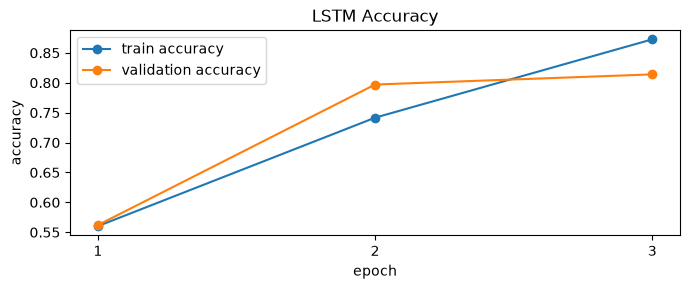

In [7]:
plt.figure(figsize=(7, 3))
plt.plot(lstm_history.history["accuracy"], marker="o", label="train accuracy")
plt.plot(lstm_history.history["val_accuracy"], marker="o", label="validation accuracy")
plt.title("LSTM Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.xticks(range(3), ["1", "2", "3"])
plt.legend()
plt.tight_layout()
plt.show()

## 4. Final Comparison

The table compares test accuracy and training time for both
approaches.

In [8]:
comparison_df = pd.DataFrame([
    {
        "model": "TF-IDF + Logistic Regression",
        "validation_accuracy": logreg_valid_acc,
        "test_accuracy": logreg_test_acc,
        "training_seconds": logreg_train_seconds,
    },
    {
        "model": "LSTM",
        "validation_accuracy": lstm_valid_acc,
        "test_accuracy": lstm_test_acc,
        "training_seconds": lstm_train_seconds,
    },
]).sort_values("test_accuracy", ascending=False)

comparison_df

,model,validation_accuracy,test_accuracy,training_seconds
0,TF-IDF + Logistic Regression,0.859,0.8600,3.861985
1,LSTM,0.814,0.8085,28.288062


## 5. Comparison Analysis - Completed

The next cell answers all five required comparison questions using
the measured results.

In [9]:
best_model = comparison_df.iloc[0]["model"]
fastest_model = comparison_df.sort_values("training_seconds").iloc[0]["model"]

answer = f'''
1. **Performance:** `{best_model}` performed better on test accuracy in this run.
2. **Training speed:** `{fastest_model}` trained faster. Logistic Regression usually trains much faster because it is a simpler linear model.
3. **Strengths and weaknesses:** TF-IDF + Logistic Regression is simple, fast, and easy to explain, but it does not understand word order well. The LSTM can use word order, but it is slower and needs more tuning/data.
4. **When to use which:** I would use TF-IDF + Logistic Regression for a quick baseline, small datasets, or limited compute. I would use an LSTM when sequence order matters and I have enough time/data to tune it.
5. **How to improve the LSTM:** Train longer, use more data, tune the embedding size and LSTM units, add dropout, try bidirectional LSTM, and compare with modern pretrained text models.
'''

display(Markdown(answer))


1. **Performance:** `TF-IDF + Logistic Regression` performed better on test accuracy in this run.
2. **Training speed:** `TF-IDF + Logistic Regression` trained faster. Logistic Regression usually trains much faster because it is a simpler linear model.
3. **Strengths and weaknesses:** TF-IDF + Logistic Regression is simple, fast, and easy to explain, but it does not understand word order well. The LSTM can use word order, but it is slower and needs more tuning/data.
4. **When to use which:** I would use TF-IDF + Logistic Regression for a quick baseline, small datasets, or limited compute. I would use an LSTM when sequence order matters and I have enough time/data to tune it.
5. **How to improve the LSTM:** Train longer, use more data, tune the embedding size and LSTM units, add dropout, try bidirectional LSTM, and compare with modern pretrained text models.
